In [12]:
# ANALISIS EXPLORATORIO
# Objetivo: tomar cuatro decisiones antes de modelar.
#   1. Transformar o no la variable objetivo
#   2. Que variables entran en el modelo
#   3. Como tratar las zonas con pocos anuncios
#   4. Que hacer con los estudios sin superficie

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_parquet("../data/processed/analytical_dataset.parquet")
print(f"{len(df)} anuncios, {len(df.columns)} columnas")
df.head(3)

886 anuncios, 27 columnas


,listing_id,fingerprint,monthly_price,area_sqm,price_per_sqm,n_rooms,typology,rooms_band,area_band,municipality,...,is_outlier,column_shift_flag,emal_rent_per_sqm,emal_mean_rent,zona_ref,zone_median_sqm,price_relative_zone,sqm_per_room,typology_grouped,gap_vs_official
0,3,6f765d87efaf037e,960.0,69.0,13.91,3,flat,3,50-80,Getxo,...,False,False,11.63,886.98,Getxo,12.61,1.103,23.0,flat,19.6
1,4,5bccc0f2e7f71c13,880.0,60.0,14.67,1,flat,1,50-80,Bilbao,...,False,False,NaN,NaN,Zabalburu-Diputación,13.79,1.064,60.0,flat,NaN
2,5,34111936ccfe753c,1100.0,85.0,12.94,3,flat,3,80-120,Bilbao,...,False,False,14.36,1000.66,Abando,15.04,0.860,28.3,flat,-9.9


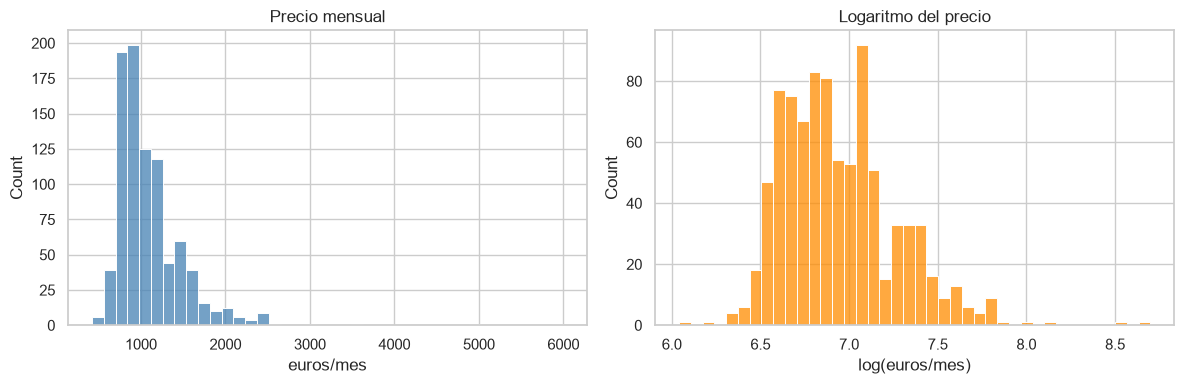

Asimetria del precio:     3.55
Asimetria del logaritmo:  0.89

count     886.0
mean     1096.0
std       432.0
min       420.0
25%       800.0
50%       980.0
75%      1250.0
max      6000.0
Name: monthly_price, dtype: float64


In [13]:
# PREGUNTA 1: como se distribuye el precio?
# Si tiene cola larga a la derecha conviene modelar el logaritmo:
# los modelos lineales asumen errores simetricos y una cola larga
# los rompe.

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["monthly_price"], bins=40, ax=ax[0], color="steelblue")
ax[0].set_title("Precio mensual")
ax[0].set_xlabel("euros/mes")

sns.histplot(np.log(df["monthly_price"]), bins=40, ax=ax[1], color="darkorange")
ax[1].set_title("Logaritmo del precio")
ax[1].set_xlabel("log(euros/mes)")

plt.tight_layout()
plt.show()

print(f"Asimetria del precio:     {df['monthly_price'].skew():.2f}")
print(f"Asimetria del logaritmo:  {np.log(df['monthly_price']).skew():.2f}")
print()
print(df["monthly_price"].describe().round(0))

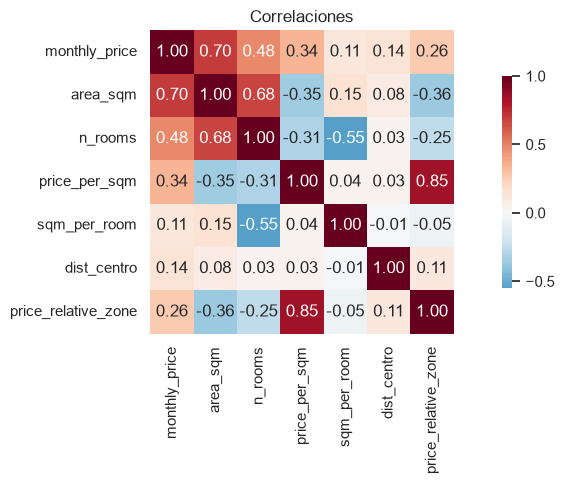

Correlacion con el precio, de mayor a menor:
area_sqm               0.701
n_rooms                0.476
price_per_sqm          0.340
price_relative_zone    0.264
dist_centro            0.139
sqm_per_room           0.115
Name: monthly_price, dtype: float64


In [14]:
# PREGUNTA 2: que variables aportan y cuales se solapan?

numericas = ["monthly_price", "area_sqm", "n_rooms", "price_per_sqm",
             "sqm_per_room", "dist_centro", "price_relative_zone"]

corr = df[numericas].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlaciones")
plt.tight_layout()
plt.show()

print("Correlacion con el precio, de mayor a menor:")
print(corr["monthly_price"].drop("monthly_price").sort_values(ascending=False).round(3))

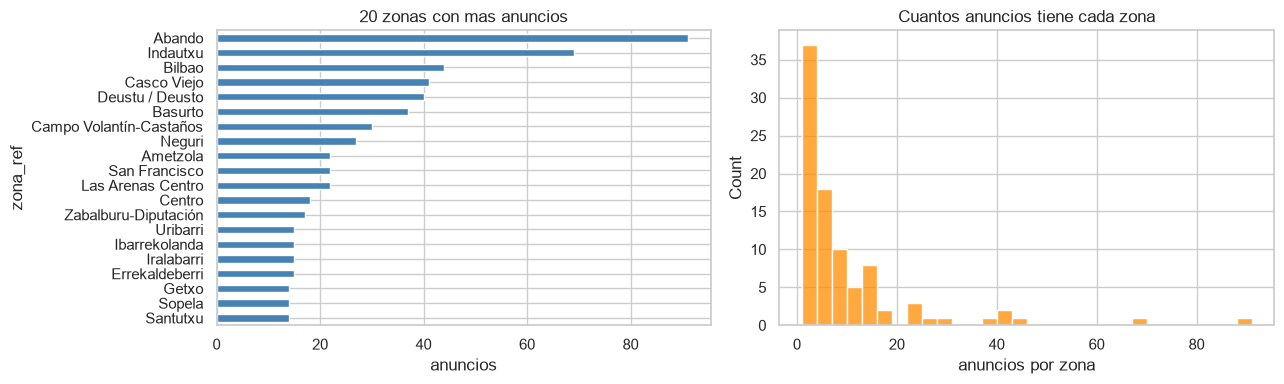

  zonas con  1+ anuncios:  91  (886 anuncios, 100 % del total)
  zonas con  5+ anuncios:  43  (766 anuncios, 86 % del total)
  zonas con 10+ anuncios:  26  (647 anuncios, 73 % del total)
  zonas con 20+ anuncios:  11  (445 anuncios, 50 % del total)
  zonas con 30+ anuncios:   7  (352 anuncios, 40 % del total)


In [15]:
# PREGUNTA 3: cuantas zonas tienen muestra suficiente?
# Una categoria con uno o dos casos no se puede aprender: el modelo
# memoriza en lugar de generalizar.

conteo = df["zona_ref"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

conteo.head(20).plot(kind="barh", ax=ax[0], color="steelblue")
ax[0].invert_yaxis()
ax[0].set_title("20 zonas con mas anuncios")
ax[0].set_xlabel("anuncios")

sns.histplot(conteo.values, bins=30, ax=ax[1], color="darkorange")
ax[1].set_title("Cuantos anuncios tiene cada zona")
ax[1].set_xlabel("anuncios por zona")

plt.tight_layout()
plt.show()

for umbral in [1, 5, 10, 20, 30]:
    zonas = (conteo >= umbral).sum()
    anuncios = conteo[conteo >= umbral].sum()
    print(f"  zonas con {umbral:2d}+ anuncios: {zonas:3d}  "
          f"({anuncios} anuncios, {anuncios/len(df)*100:.0f} % del total)")

Registros sin superficie: 27

typology
studio    27
Name: count, dtype: int64

Precio de los estudios frente al resto:
          count    mean    std    min    25%    50%     75%     max
area_sqm                                                           
False     859.0  1106.0  434.0  550.0  825.0  990.0  1250.0  6000.0
True       27.0   783.0  194.0  420.0  685.0  750.0   850.0  1350.0


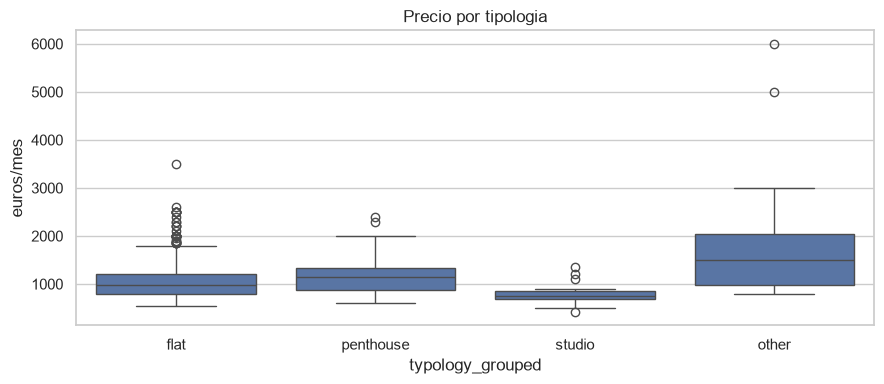

In [16]:
# PREGUNTA 4: que hacemos con los 27 estudios sin superficie?

sin_sup = df["area_sqm"].isna()
print(f"Registros sin superficie: {sin_sup.sum()}")
print()
print(df.loc[sin_sup, "typology"].value_counts())
print()
print("Precio de los estudios frente al resto:")
print(df.groupby(sin_sup)["monthly_price"].describe().round(0))

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="typology_grouped", y="monthly_price", ax=ax)
ax.set_title("Precio por tipologia")
ax.set_ylabel("euros/mes")
plt.tight_layout()
plt.show()

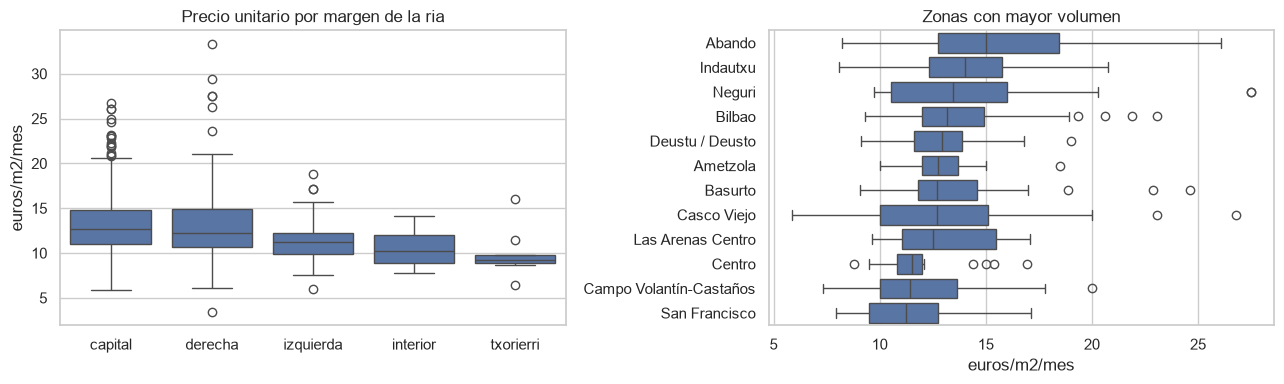

In [17]:
# Contexto territorial: el gradiente que ya conocemos, ahora en grafico.
# Este va directo a la memoria.

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

orden = df.groupby("river_bank")["price_per_sqm"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="river_bank", y="price_per_sqm", order=orden, ax=ax[0])
ax[0].set_title("Precio unitario por margen de la ria")
ax[0].set_ylabel("euros/m2/mes")
ax[0].set_xlabel("")

top = df["zona_ref"].value_counts().head(12).index
sub = df[df["zona_ref"].isin(top)]
orden2 = sub.groupby("zona_ref")["price_per_sqm"].median().sort_values(ascending=False).index
sns.boxplot(data=sub, y="zona_ref", x="price_per_sqm", order=orden2, ax=ax[1])
ax[1].set_title("Zonas con mayor volumen")
ax[1].set_xlabel("euros/m2/mes")
ax[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [18]:
# SOLUCION AL PROBLEMA 3: agrupacion de zonas en dos niveles
#
# Nivel 1: si el barrio tiene 5 o mas anuncios, se conserva
# Nivel 2: si no, se agrupa en "otros" de su municipio
# Nivel 3: si ese "otros" tampoco llega a 5, se agrupa por
#          margen de la ria, que es una unidad territorial con
#          sentido y siempre tiene volumen suficiente

UMBRAL = 5

df["zona_id"] = df["municipality"] + "|" + df["zona_ref"].fillna("sin_barrio")

# Nivel 1 y 2
conteo = df["zona_id"].value_counts()
zonas_ok = conteo[conteo >= UMBRAL].index
df["zona_modelo"] = np.where(
    df["zona_id"].isin(zonas_ok),
    df["zona_id"],
    df["municipality"] + "|otros"
)

# Nivel 3: los "otros" que siguen siendo pequenos van al margen
conteo2 = df["zona_modelo"].value_counts()
pequenas = conteo2[conteo2 < UMBRAL].index
df["zona_modelo"] = np.where(
    df["zona_modelo"].isin(pequenas),
    "margen|" + df["river_bank"].fillna("sin_clasificar"),
    df["zona_modelo"]
)

final = df["zona_modelo"].value_counts()
print(f"Zonas antes:   {df['zona_ref'].nunique()}")
print(f"Zonas despues: {df['zona_modelo'].nunique()}")
print(f"Minimo de anuncios por zona: {final.min()}")
print(f"Zonas por debajo del umbral: {(final < UMBRAL).sum()}")
print()
print("Las 12 mayores:")
print(final.head(12))
print()
print("Categorias agregadas:")
print(final[final.index.str.contains(r"\|otros|^margen\|")])

Zonas antes:   91
Zonas despues: 54
Minimo de anuncios por zona: 4
Zonas por debajo del umbral: 1

Las 12 mayores:
zona_modelo
Bilbao|Abando                     91
Bilbao|Indautxu                   69
Bilbao|Bilbao                     44
Bilbao|Casco Viejo                41
Bilbao|Deustu / Deusto            40
Bilbao|Basurto                    37
Bilbao|Campo Volantín-Castaños    30
Getxo|Neguri                      27
Bilbao|otros                      24
Bilbao|Ametzola                   22
Bilbao|San Francisco              22
Getxo|Las Arenas Centro           22
Name: count, dtype: int64

Categorias agregadas:
zona_modelo
Bilbao|otros         24
Santurtzi|otros      16
Getxo|otros          16
Leioa|otros          14
Portugalete|otros    12
margen|derecha       11
margen|txorierri      9
Barakaldo|otros       9
margen|interior       7
margen|izquierda      4
Name: count, dtype: int64


In [19]:
# RESUMEN DE DECISIONES TOMADAS
#
# 1. Variable objetivo: se modela el LOGARITMO del precio.
#    Asimetria de 3,55 en el precio frente a 0,89 en el logaritmo.
#
# 2. Variables excluidas del modelo de precio:
#    price_per_sqm y price_relative_zone se derivan del propio precio.
#    Incluirlas permitiria al modelo reconstruir el objetivo.
#    Se reservan para el modulo de deteccion de anomalias.
#
# 3. Zonas: agrupacion en tres niveles hasta garantizar un minimo
#    de observaciones por categoria. De 91 zonas a 54.
#
# 4. Estudios: los 27 registros sin superficie quedan fuera del
#    modelo de precio por carecer de la variable mas explicativa.

# dist_centro se descarta: solo esta disponible en el 40 % de los
# registros, porque los anuncios de la capital apuntan a
# denominaciones comerciales que carecen de geometria. La
# localizacion queda recogida por zona_modelo y river_bank.
MODELO_COLS = [
    "area_sqm", "n_rooms", "sqm_per_room",
    "typology_grouped", "zona_modelo", "river_bank",
]
OBJETIVO = "monthly_price"

modelo_df = df[df["area_sqm"].notna()].copy()

print(f"Conjunto de modelizacion: {len(modelo_df)} registros")
print(f"Variables predictoras: {len(MODELO_COLS)}")
print()
print("Valores ausentes en las predictoras:")
print(modelo_df[MODELO_COLS].isna().sum())

# Se guarda para la fase de modelizacion
modelo_df.to_parquet("../data/processed/model_dataset.parquet", index=False)
print()
print("Guardado en data/processed/model_dataset.parquet")

Conjunto de modelizacion: 859 registros
Variables predictoras: 6

Valores ausentes en las predictoras:
area_sqm            0
n_rooms             0
sqm_per_room        0
typology_grouped    0
zona_modelo         0
river_bank          0
dtype: int64

Guardado en data/processed/model_dataset.parquet
